# Dataset and Lib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#config diagram interface

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

In [3]:
df = pd.read_csv('../content/train.csv')
print(df.head(10))
print(df.tail(10))

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   
5   6          50       RL         85.0    14115   Pave   NaN      IR1   
6   7          20       RL         75.0    10084   Pave   NaN      Reg   
7   8          60       RL          NaN    10382   Pave   NaN      IR1   
8   9          50       RM         51.0     6120   Pave   NaN      Reg   
9  10         190       RL         50.0     7420   Pave   NaN      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1         Lvl    AllPub  ...       

=== THỐNG KÊ MÔ TẢ SALEPRICE (GỐC) ===
Giá trung bình (Mean) : $180,921.20
Giá trung vị (Median) : $163,000.00
Độ lệch (Skewness) : 1.8829 (>0: Lệch phải)
Độ nhọn (Kurtosis) : 6.5363


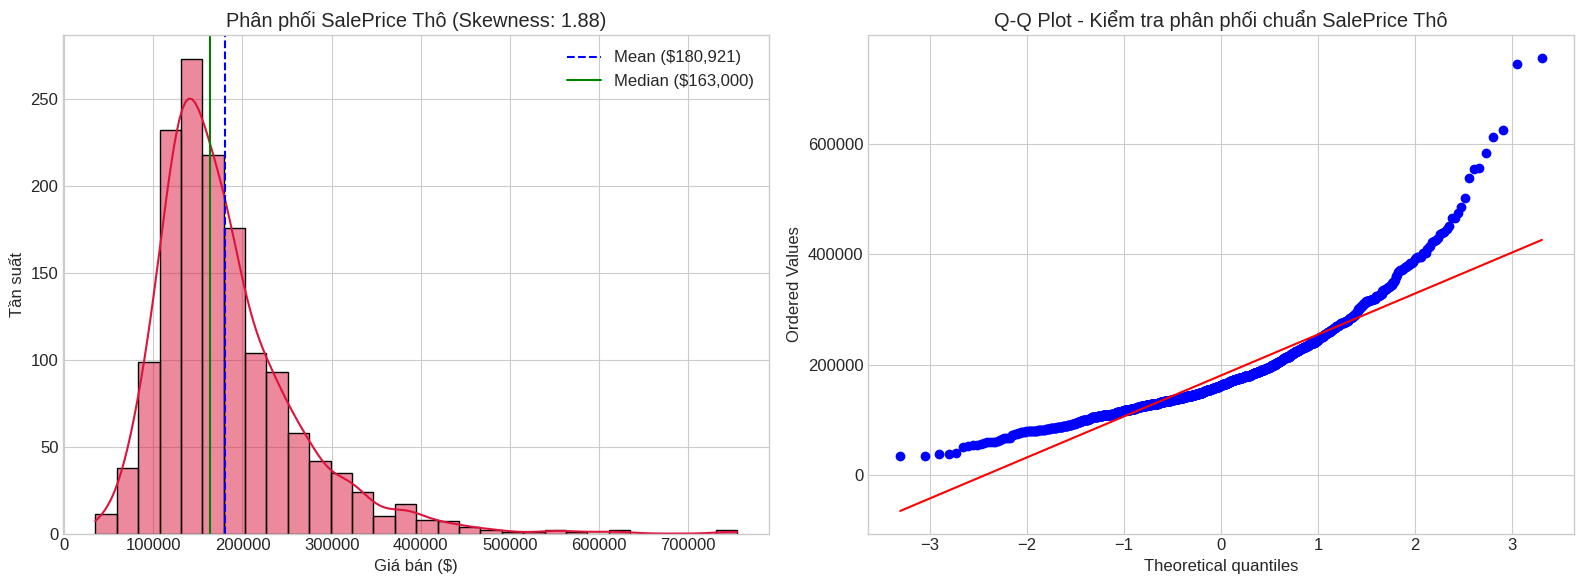

In [4]:
# Tính toán các chỉ số thống kê mô tả cho SalePrice
mean_val = df['SalePrice'].mean()
median_val = df['SalePrice'].median()
skew_val = df['SalePrice'].skew()
kurt_val = df['SalePrice'].kurt()

print("=== THỐNG KÊ MÔ TẢ SALEPRICE (GỐC) ===")
print(f"Giá trung bình (Mean) : ${mean_val:,.2f}")
print(f"Giá trung vị (Median) : ${median_val:,.2f}")
print(f"Độ lệch (Skewness) : {skew_val:.4f} (>0: Lệch phải)")
print(f"Độ nhọn (Kurtosis) : {kurt_val:.4f}")

# Trực quan hóa Histogram & Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Histogram & KDE
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='crimson', bins=30)

axes[0].axvline(mean_val, color='blue', linestyle='--', label=f'Mean (${mean_val:,.0f})')
axes[0].axvline(median_val, color='green', linestyle='-', label=f'Median (${median_val:,.0f})')
axes[0].set_title(f'Phân phối SalePrice Thô (Skewness: {skew_val:.2f})')
axes[0].set_xlabel('Giá bán ($)')
axes[0].set_ylabel('Tần suất')
axes[0].legend()

# Biểu đồ 2: Q-Q Plot kiểm tra giả định chuẩn
stats.probplot(df['SalePrice'], plot=axes[1])

axes[1].set_title('Q-Q Plot - Kiểm tra phân phối chuẩn SalePrice Thô')

plt.tight_layout()
plt.show()

=== THỐNG KÊ MÔ TẢ SALEPRICE SAU LOG1P ===
Độ lệch mới (Skewness) : 0.1213
Độ nhọn mới (Kurtosis) : 0.8095


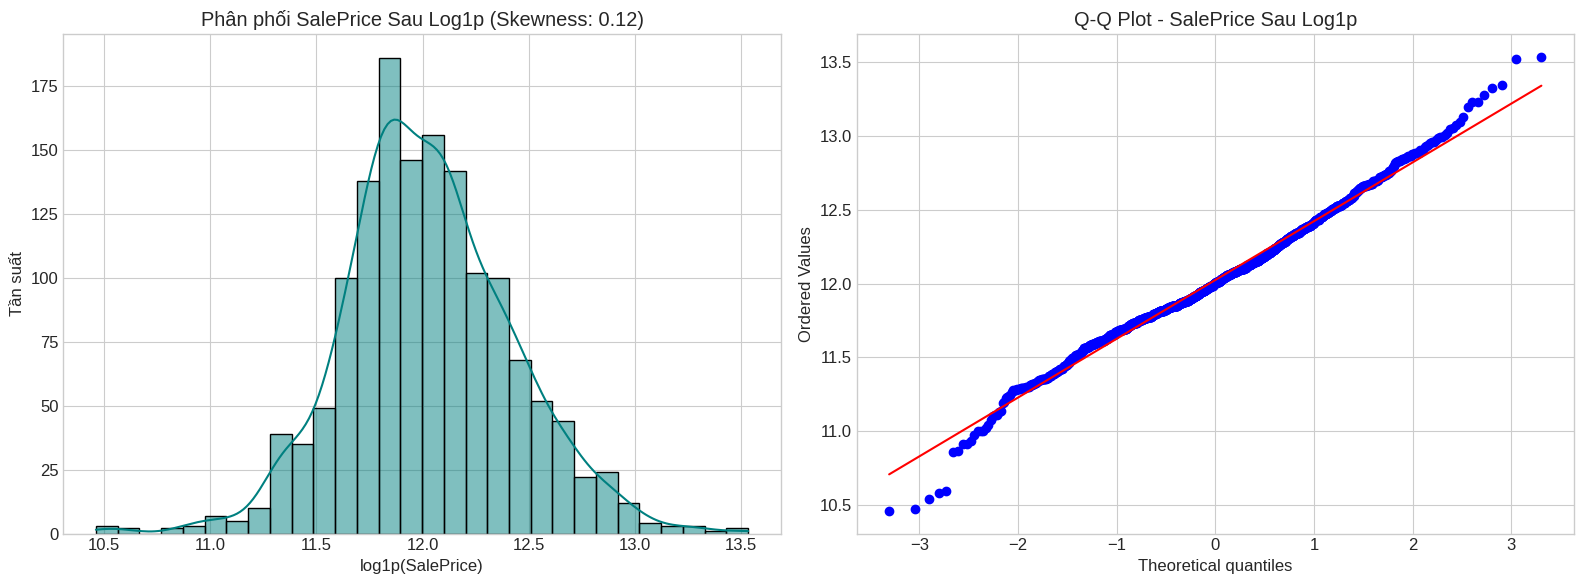

In [5]:
# Thực hiện biến đổi log1p cho biến mục tiêu
df['SalePrice_log'] = np.log1p(df['SalePrice'])

log_skew = df['SalePrice_log'].skew()
log_kurt = df['SalePrice_log'].kurt()

print("=== THỐNG KÊ MÔ TẢ SALEPRICE SAU LOG1P ===")
print(f"Độ lệch mới (Skewness) : {log_skew:.4f}")
print(f"Độ nhọn mới (Kurtosis) : {log_kurt:.4f}")

# Trực quan hóa kết quả sau chuẩn hóa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ Histogram sau khi log1p
sns.histplot(
    df['SalePrice_log'],
    kde=True,
    ax=axes[0],
    color='teal',
    bins=30
)

axes[0].set_title(
    f'Phân phối SalePrice Sau Log1p (Skewness: {log_skew:.2f})'
)

axes[0].set_xlabel('log1p(SalePrice)')
axes[0].set_ylabel('Tần suất')

# Q-Q Plot sau khi log1p
stats.probplot(
    df['SalePrice_log'],
    plot=axes[1]
)

axes[1].set_title('Q-Q Plot - SalePrice Sau Log1p')

plt.tight_layout()
plt.show()

In [6]:
# Kiểm tra tỷ lệ nhãn chiếm ưu thế trên tất cả các biến phân loại
cat_cols = df.select_dtypes(include=['object', 'category']).columns

nzv_report = []

for col in cat_cols:
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    top_label = df[col].value_counts().index[0]

    nzv_report.append({
        'Variable': col,
        'Top_Label': top_label,
        'Ratio': top_freq
    })

nzv_df = pd.DataFrame(nzv_report).sort_values(
    by='Ratio',
    ascending=False
)

print("=== CÁC BIẾN CÓ TỶ LỆ MẤT CÂN BẰNG CAO (>90%) ===")
print(nzv_df[nzv_df['Ratio'] > 0.90])

# Xác định các biến vượt ngưỡng 99% để loại bỏ
cols_to_drop = nzv_df[
    nzv_df['Ratio'] > 0.99
]['Variable'].tolist()

print(
    f"\n[XÁC NHẬN LOẠI BỎ] Các biến Near-Zero Variance (>99%): {cols_to_drop}"
)

# Thực hiện xóa cột
df_cleaned = df.drop(columns=cols_to_drop)

print(
    f"Kích thước dữ liệu sau khi loại bỏ biến NZV: {df_cleaned.shape}"
)

=== CÁC BIẾN CÓ TỶ LỆ MẤT CÂN BẰNG CAO (>90%) ===
       Variable Top_Label     Ratio
5     Utilities    AllPub  0.999315
1        Street      Pave  0.995890
10   Condition2      Norm  0.989726
14     RoofMatl   CompShg  0.982192
26      Heating      GasA  0.978082
36   GarageCond        TA  0.961566
35   GarageQual        TA  0.950689
7     LandSlope       Gtl  0.946575
28   CentralAir         Y  0.934932
31   Functional       Typ  0.931507
22     BsmtCond        TA  0.921293
37   PavedDrive         Y  0.917808
29   Electrical     SBrkr  0.914325
40  MiscFeature      Shed  0.907407

[XÁC NHẬN LOẠI BỎ] Các biến Near-Zero Variance (>99%): ['Utilities', 'Street']
Kích thước dữ liệu sau khi loại bỏ biến NZV: (1460, 80)


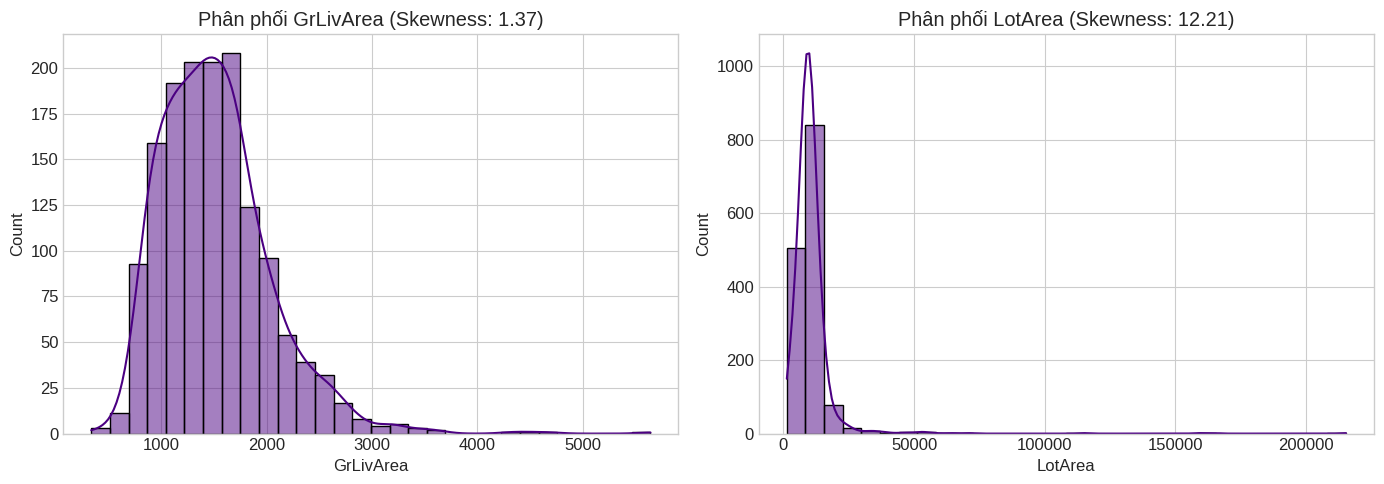

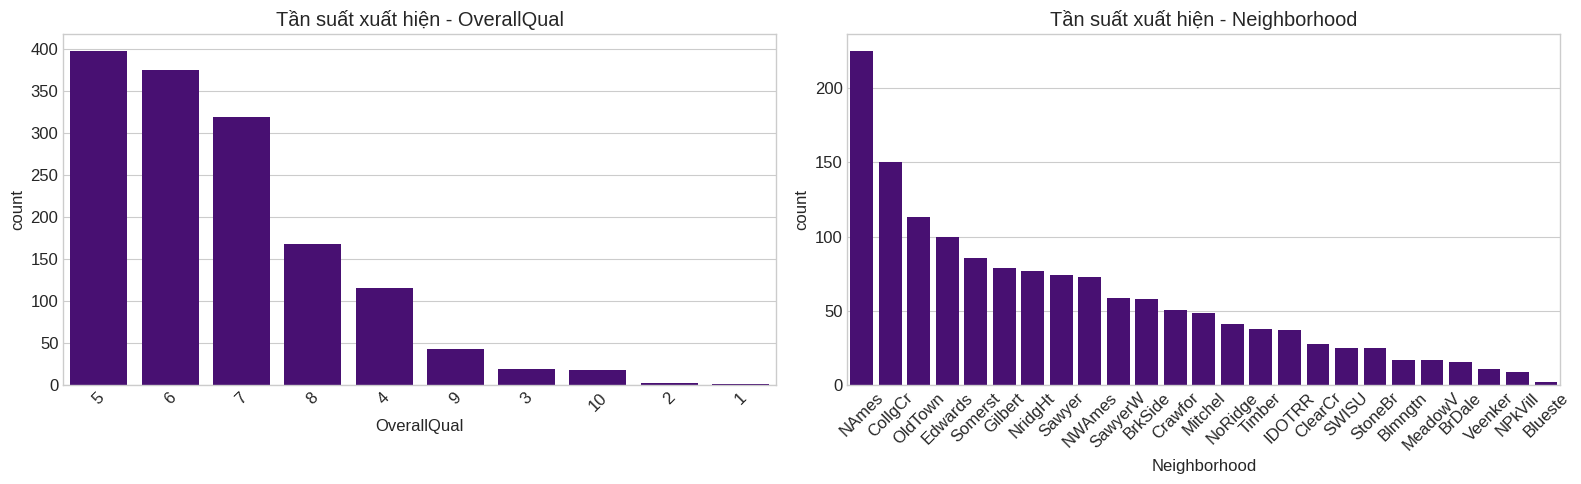

In [7]:
# 1. Biến số học: Diện tích sống (GrLivArea) & Diện tích đất (LotArea)
num_features = ['GrLivArea', 'LotArea']

existing_num = [c for c in num_features if c in df_cleaned.columns]

if existing_num:
    fig, axes = plt.subplots(1, len(existing_num), figsize=(14, 5))

    if len(existing_num) == 1:
        axes = [axes]

    for i, col in enumerate(existing_num):
        sns.histplot(
            df_cleaned[col],
            kde=True,
            ax=axes[i],
            color='indigo',
            bins=30
        )

        axes[i].set_title(
            f'Phân phối {col} (Skewness: {df_cleaned[col].skew():.2f})'
        )

    plt.tight_layout()
    plt.show()


# 2. Biến phân loại/thứ tự: Chất lượng tổng thể (OverallQual) & Khu dân cư (Neighborhood)
cat_features = ['OverallQual', 'Neighborhood']

existing_cat = [c for c in cat_features if c in df_cleaned.columns]

if existing_cat:
    fig, axes = plt.subplots(1, len(existing_cat), figsize=(16, 5))

    if len(existing_cat) == 1:
        axes = [axes]

    for i, col in enumerate(existing_cat):
        order = df_cleaned[col].value_counts().index

        sns.countplot(
            data=df_cleaned,
            x=col,
            ax=axes[i],
            color='indigo',
            order=order
        )

        axes[i].set_title(
            f'Tần suất xuất hiện - {col}'
        )

        axes[i].tick_params(
            axis='x',
            rotation=45
        )

    plt.tight_layout()
    plt.show()

In [8]:
# Lưu dữ liệu sạch đã log1p SalePrice và loại bỏ các biến Near-Zero Variance
output_file = 'ames_train_univariate_scaled.csv'

df_cleaned.to_csv(output_file, index=False)

print(f"✅ Đã bàn giao thành công file: {output_file}")
print(f"Tổng số cột hiện tại: {df_cleaned.shape[1]}")

✅ Đã bàn giao thành công file: ames_train_univariate_scaled.csv
Tổng số cột hiện tại: 80
